In [72]:
# ニューラルネットワークの復習
# ベクトルと行列
import numpy as np

x = np.array([1, 2, 3])
x.__class__

numpy.ndarray

In [73]:
x.shape

(3,)

In [74]:
x.ndim

1

In [75]:
W = np.array([[1, 2, 3], [4, 5, 6]])
W.shape

(2, 3)

In [76]:
W.ndim

2

In [77]:
 # 行列の要素ごとの演算
W = np.array([[1, 2, 3], [4, 5, 6]])
X = np.array([[0, 1, 2], [3, 4, 5]])
W + X

array([[ 1,  3,  5],
       [ 7,  9, 11]])

In [78]:
W * X

array([[ 0,  2,  6],
       [12, 20, 30]])

In [79]:
# ブロードキャスト
A = np.array([[1, 2], [3, 4]])
A * 10

array([[10, 20],
       [30, 40]])

In [80]:
# ベクトルの内積
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
a @ b

np.int64(32)

In [81]:
# 行列の積
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
A @ B

array([[19, 22],
       [43, 50]])

In [82]:
# ニューラルネットワークの推論の全体図

In [83]:
# ミニバッチ版の全結合層による変換
import numpy as np

rng = np.random.default_rng()

W1 = rng.random((2, 4))
b1 = rng.random(4)
x = rng.random((10, 2))
h = x @ W1 + b1

In [84]:
# シグモイド関数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

a = sigmoid(h)

In [85]:
# レイヤとしてのクラス化と順伝播の実装

In [86]:
# シグモイドレイヤ
import numpy as np

class Sigmoid:
    def __init__(self):
        self.params = []
    
    def forward(self, x):
        return 1 / (1 + np.exp(-x))

In [87]:
# Affineレイヤ
class Affine:
    def __init__(self, W, b):
        self.params = [W, b]

    def forward(self, x):
        W, b = self.params
        out = x @ W + b
        return out

In [88]:
# TwoLayerNetの実装

rng = np.random.default_rng

class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size):
        I, H, O = input_size, hidden_size, output_size

        # 重みとバイアスの初期化
        W1 = rng.random((I, H))
        b1 = rng.random(H)
        W2 = rng.random((H, O))
        b2 = rng.random(O)

        # レイヤの生成
        self.layers = [
            Affine(W1, b1),
            Sigmoid(),
            Affine(W2, b2)
        ]

        # 全ての重みをリストにまとめる
        self.params = []
        for layer in self.layers:
            self.params += layer.params

    def predict(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x


In [89]:
rng = np.random.default_rng()

x = rng.random((10, 2))
model = TwoLayerNet(2, 4, 3)
s = model.predict(x)

In [90]:
# ニューラルネットワークの学習
# 損失関数
# 微分と勾配
# チェインルール

In [91]:
# Repeatノード
import numpy as np

rng = np.random.default_rng()

D, N = 8, 7
x = rng.random((1, D))
y = np.repeat(x, N, axis=0)

dy = rng.random((N, D))
dx = np.sum(dy, axis=0, keepdims=True)

In [92]:
# Sumノード
import numpy as np

rng = np.random.default_rng()

D, N = 8, 7
x = rng.random((N, D))
y = np.sum(x, axis=0, keepdims=True)

dy = rng.random((1, D))
dx = np.repeat(dy, N, axis=0)

In [93]:
# MatMulノード
class MatMul:
    def __init__ (self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.x = None

    def forward(self, x):
        W, = self.params
        out = x @ W
        self.x = x
        return out

    def backward(self, dout):
        W, = self.params
        dx = dout @ W.T
        dW = self.x.T @ dout
        self.grads[0][...] = dW
        return dx

In [94]:
# 勾配の導出と逆伝播の実装
# Sigmoidレイヤの実装
class Sigmoid:
    def __init__ (self):
        self.params, self.grads = [], []
        self.out = None

    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out
        return out

    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out
        return dx

In [95]:
# Affineレイヤ
class Affine:
    def __init__ (self, W, b):
        self.params = [W, b]
        self.grads = [np.zeros_like(W), np.zeros_like(b)]
        self.x = None

    def forward(self, x):
        W, b = self.params
        out = X @ W + b
        self.x = x
        return out

    def backward(self, dout):
        W, b = self.params
        dx = dout @ W.T
        dW = self.x.T @ dout
        db = np.sum(dout, axis=0)

        self.grads[0][...] = dW
        self.grads[1][...] = db
        return dx

In [96]:
# 重みの更新

In [97]:
# SGDの実装
class SGD:
    def __init__ (self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for i in range(len(params)):
            params[i] -= self.lr * grads[i]

In [98]:
# ニューラルネットワークで問題解く

In [99]:
import sys
sys.path.append("..")
from dataset import spiral
import matplotlib.pyplot as plt

x, t = spiral.load_data()
print("x", x.shape)
print("t", t.shape)

x (300, 2)
t (300, 3)


In [101]:
# ニューラルネットワークの実装
import sys
sys.path.append("..")
import numpy as np
from common.layers import Affine, Sigmoid, SoftmaxWithLoss

rng = np.random.default_rng()

class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size):
        I, H, O = input_size, hidden_size, output_size

        # 重みとバイアスの初期化
        W1 = 0.01 * rng.random((I, H))
        b1 = np.zeros(H)
        W2 = 0.01 * rng.random((H, O))
        b2 = np.zeros(O)

        # レイヤの生成
        self.layers = [
            Affine(W1, b1),
            Sigmoid(),
            Affine(W2, b2)
        ]
        self.loss_layer = SoftmaxWithLoss()

        # 全ての重みと勾配をリストにまとめる
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

In [102]:
# TwoLayNetに3つのメソッドを追加する
# predict()メソッド
def predict(self, x):
    for layer in self.layers:
        x = layer.forward(x)
    return x

# forward()メソッド
def forward(self, x, t):
    score = self.predict(x)
    loss = self.loss_layer.forward(score, t)
    return loss

# backward()メソッド
def backward(self, dout=1):
    dout = self.loss_layer.backward(dout)
    for layer in reversed(self.layers):
        dout = layer.backward(dout)
    return dout

| epoch 1 |  iter 10 / 10 | loss 1.13
| epoch 2 |  iter 10 / 10 | loss 1.13
| epoch 3 |  iter 10 / 10 | loss 1.12
| epoch 4 |  iter 10 / 10 | loss 1.12
| epoch 5 |  iter 10 / 10 | loss 1.11
| epoch 6 |  iter 10 / 10 | loss 1.14
| epoch 7 |  iter 10 / 10 | loss 1.16
| epoch 8 |  iter 10 / 10 | loss 1.11
| epoch 9 |  iter 10 / 10 | loss 1.12
| epoch 10 |  iter 10 / 10 | loss 1.13
| epoch 11 |  iter 10 / 10 | loss 1.12
| epoch 12 |  iter 10 / 10 | loss 1.11
| epoch 13 |  iter 10 / 10 | loss 1.09
| epoch 14 |  iter 10 / 10 | loss 1.08
| epoch 15 |  iter 10 / 10 | loss 1.04
| epoch 16 |  iter 10 / 10 | loss 1.03
| epoch 17 |  iter 10 / 10 | loss 0.96
| epoch 18 |  iter 10 / 10 | loss 0.92
| epoch 19 |  iter 10 / 10 | loss 0.92
| epoch 20 |  iter 10 / 10 | loss 0.87
| epoch 21 |  iter 10 / 10 | loss 0.85
| epoch 22 |  iter 10 / 10 | loss 0.82
| epoch 23 |  iter 10 / 10 | loss 0.79
| epoch 24 |  iter 10 / 10 | loss 0.78
| epoch 25 |  iter 10 / 10 | loss 0.82
| epoch 26 |  iter 10 / 10 | loss 

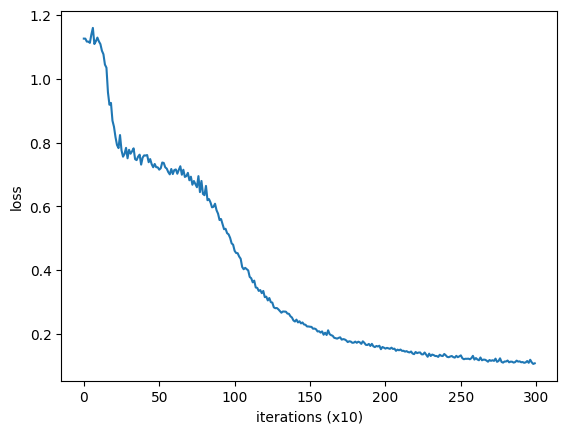

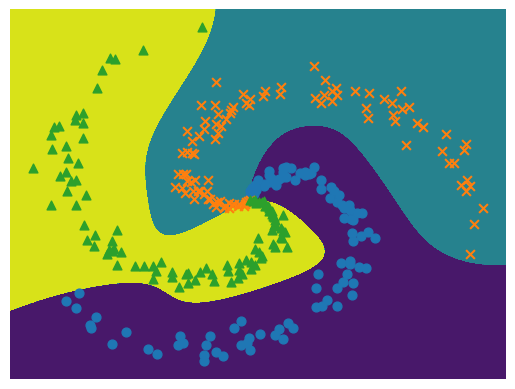

| epoch 1 |   iter 10 / 10 | loss 1.10
| epoch 2 |   iter 10 / 10 | loss 1.12
| epoch 3 |   iter 10 / 10 | loss 1.10
| epoch 4 |   iter 10 / 10 | loss 1.08
| epoch 5 |   iter 10 / 10 | loss 1.18
| epoch 6 |   iter 10 / 10 | loss 1.22
| epoch 7 |   iter 10 / 10 | loss 1.24
| epoch 8 |   iter 10 / 10 | loss 1.13
| epoch 9 |   iter 10 / 10 | loss 1.12
| epoch 10 |   iter 10 / 10 | loss 1.20
| epoch 11 |   iter 10 / 10 | loss 1.22
| epoch 12 |   iter 10 / 10 | loss 1.22
| epoch 13 |   iter 10 / 10 | loss 1.10
| epoch 14 |   iter 10 / 10 | loss 1.12
| epoch 15 |   iter 10 / 10 | loss 1.24
| epoch 16 |   iter 10 / 10 | loss 1.32
| epoch 17 |   iter 10 / 10 | loss 1.16
| epoch 18 |   iter 10 / 10 | loss 1.10
| epoch 19 |   iter 10 / 10 | loss 1.13
| epoch 20 |   iter 10 / 10 | loss 1.12
| epoch 21 |   iter 10 / 10 | loss 1.06
| epoch 22 |   iter 10 / 10 | loss 1.42
| epoch 23 |   iter 10 / 10 | loss 1.11
| epoch 24 |   iter 10 / 10 | loss 1.17
| epoch 25 |   iter 10 / 10 | loss 1.06
| epoch 2

In [103]:
# 学習用のソースコード
from pickletools import optimize
import sys

from ch01.train_custom_loop import batch_t, batch_x, loss_list
sys.path.append("..")
import numpy as np
from common.optimizer import SGD
from dataset import spiral
import matplotlib.pyplot as plt
from two_layer_net import TwoLayerNet

# ハイパーパラメータの設定
max_epoch = 300
batch_size = 30
hidden_size = 10
learning_rate = 1.0

# データの読み込み、モデルとオプティマイザの生成
x, t = spiral.load_data()
model = TwoLayerNet(input_size=2, hidden_size=hidden_size, output_size=3)
optimizer = SGD(lr=learning_rate)

# 学習で使用する変数
data_size = len(x)
max_iters = data_size // batch_size
total_loss = 0
loss_count = 0
loss_list = []

for epoch in range(max_epoch):
    # データのシャッフル
    idx = np.random.permutation(data_size)
    x = x[idx]
    t = t[idx]

    for iters in range(max_iters):
         batch_x = x[iters*batch_size:(iters+1)*batch_size]
         batch_t = t[iters*batch_size:(iters+1)*batch_size]

        # 勾配を求め、パラメータを更新
    loss = model.forward(batch_x, batch_t)
    model.backward()
    optimizer.update(model.params, model.grads)

    total_loss += loss
    loss_count += 1

    # 定期的に学習経過を出力
    if (iters+1) % 10 == 0:
        avg_loss = total_loss / loss_count
        print("| epoch %d |   iter %d / %d | loss %.2f"
        % (epoch + 1, iters + 1, max_iters, avg_loss))
        loss_list.append(avg_loss)
        total_loss, loss_count = 0, 0



In [ ]:
#